In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame

print("Shape:", df.shape)                    # expect (569, 31)
print("\nClass distribution:")
print(df['target'].value_counts())           # 0 = malignant, 1 = benign
print("\nMissing values total:", df.isnull().sum().sum())
df.head()

Shape: (569, 31)

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing values total: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# --- Deliberately inject missing values to demonstrate imputation (Task 2) ---
# The dataset is complete; we introduce ~3% missing values on purpose
# so we can demonstrate the imputation step of the preprocessing pipeline.

from sklearn.impute import SimpleImputer

# Work on a copy so the original stays intact
df_missing = df.copy()

# Separate features from target — we only inject missingness into FEATURES, never the label
X = df_missing.drop(columns='target')
y = df_missing['target']

# Randomly set ~3% of feature cells to NaN
rng = np.random.default_rng(42)          # fixed seed = reproducible
mask = rng.random(X.shape) < 0.03        # True for ~3% of cells
X = X.mask(mask)                          # set those cells to NaN

print("Missing values after injection:", X.isnull().sum().sum())
print("Fraction missing:", X.isnull().sum().sum() / X.size)

Missing values after injection: 494
Fraction missing: 0.02893966022261277


In [3]:
# --- Impute missing values (Task 2) ---
# Fill NaNs with the MEDIAN of each column.
# Median (not mean) because it's robust to outliers, and this dataset
# has skewed features (area, perimeter) where a few large tumors would
# drag the mean upward.

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Missing values after imputation:", X_imputed.isnull().sum().sum())  # expect 0
X_imputed.head()

Missing values after imputation: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.330,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,25.465,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.530,152.50,1709.0,0.1312,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.500,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.670,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07987


In [4]:
X_imputed.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.096624,19.310510,92.194824,653.991388,0.096494,0.104062,0.087437,0.048961,0.181314,0.062741,...,16.170482,25.758216,107.327768,868.459930,0.132078,0.253837,0.271538,0.114322,0.290385,0.083744
std,3.503310,4.277015,24.158690,349.230677,0.013840,0.051837,0.078910,0.038536,0.027009,0.007001,...,4.734146,6.035194,33.176612,546.799286,0.022520,0.156293,0.207767,0.065457,0.061310,0.017873
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.710000,16.320000,75.460000,423.600000,0.086750,0.066020,0.029740,0.020740,0.162800,0.057800,...,13.060000,21.430000,84.700000,515.900000,0.117100,0.148200,0.116700,0.064980,0.251300,0.071910
50%,13.290000,18.880000,86.965000,552.400000,0.096035,0.092525,0.061260,0.033600,0.179300,0.061515,...,14.915000,25.465000,97.930000,684.600000,0.131200,0.214100,0.226200,0.099100,0.282200,0.079870
75%,15.750000,21.780000,104.100000,773.500000,0.105100,0.129700,0.120400,0.073400,0.195300,0.066010,...,18.220000,29.460000,124.300000,1035.000000,0.145000,0.333100,0.380900,0.161300,0.317400,0.091800
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [5]:
# --- Feature scaling (Task 2) ---
# Standardize features to mean=0, std=1 using StandardScaler.
# REQUIRED before PCA: PCA finds directions of maximum variance, so if
# features are on different scales (e.g. 'area' in the hundreds vs
# 'smoothness' near 0.1), the large-scale features dominate the variance
# purely because of their units — not because they're more informative.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

# Verify: every column should now have mean ≈ 0 and std ≈ 1
print("Means (should be ~0):")
print(X_scaled.mean().round(3).head())
print("\nStd devs (should be ~1):")
print(X_scaled.std().round(3).head())

Means (should be ~0):
mean radius        0.0
mean texture       0.0
mean perimeter     0.0
mean area          0.0
mean smoothness   -0.0
dtype: float64

Std devs (should be ~1):
mean radius        1.001
mean texture       1.001
mean perimeter     1.001
mean area          1.001
mean smoothness    1.001
dtype: float64


Components for ~90% variance: 8
Components for ~95% variance: 12

Variance from first 5 components: 0.829


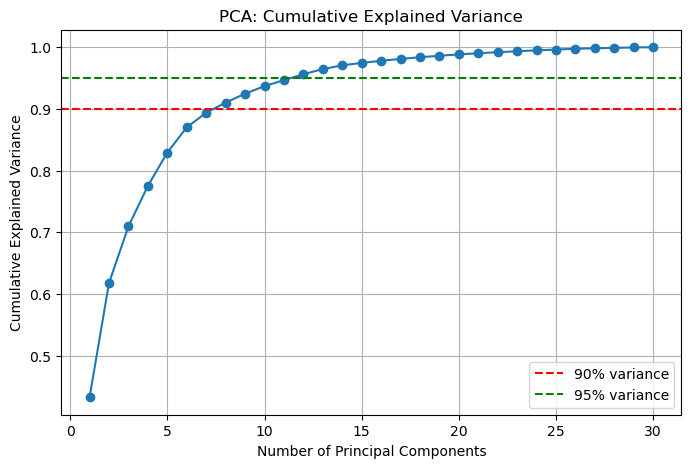

In [6]:
# --- PCA (Task 3) ---
# Fit PCA on the scaled data, keeping ALL components first so we can
# examine how variance accumulates.

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_scaled)

# Cumulative explained variance as we add components
cumvar = np.cumsum(pca.explained_variance_ratio_)

# How many components to reach 90% and 95%?
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

print(f"Components for ~90% variance: {n_90}")
print(f"Components for ~95% variance: {n_95}")
print(f"\nVariance from first 5 components: {cumvar[4]:.3f}")

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# --- Build feature sets for modeling (Task 4 prep) ---
# We will train models on TWO feature representations:
#   1. X_scaled      -> original 30 scaled features (baseline)
#   2. X_pca         -> PCA-transformed features preserving 95% variance (12 components)
# Both use the SAME scaled data as input, so the only difference is
# whether PCA dimensionality reduction was applied. This makes the
# comparison fair.

# Transform to 12 components (95% variance)
pca_95 = PCA(n_components=12)
X_pca = pca_95.fit_transform(X_scaled)

# Convert to DataFrame with named components for readability
X_pca = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(12)],
    index=X_scaled.index
)

print("Original feature set shape:", X_scaled.shape)   # (569, 30)
print("PCA feature set shape:     ", X_pca.shape)       # (569, 12)
print("Variance preserved by PCA set:", pca_95.explained_variance_ratio_.sum().round(4))
X_pca.head()

Original feature set shape: (569, 30)
PCA feature set shape:      (569, 12)
Variance preserved by PCA set: 0.9562


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,9.323774,2.013316,-1.042273,-3.666779,1.224285,1.288259,-2.297266,-0.317445,-0.220557,-0.903908,0.100380,0.704110
1,2.487243,-3.812517,-0.594199,-0.958899,-0.627688,-0.023834,0.016528,0.181817,-0.690343,1.094115,1.106113,-0.342679
2,5.759517,-1.161925,-0.421631,-0.933434,-0.005731,0.757344,0.591037,-0.066553,-0.153423,0.537086,-0.576939,-0.313277
3,7.205997,10.443768,-3.034818,-0.138884,3.120216,3.000914,-1.444513,1.012456,-1.568146,-1.106240,-0.661277,-1.613972
4,3.997212,-1.959785,1.329337,-2.976959,-0.623450,-1.263676,0.875279,0.573211,-0.216551,0.353519,0.777518,0.111127


In [8]:
# --- Task 4: Model Development ---
# Three classifiers, each trained on TWO feature representations:
#   (1) original features   (2) PCA-transformed features (95% variance)
#
# We use Pipelines so that imputation, scaling, and PCA are fit ONLY on
# training data during cross-validation — preventing data leakage.

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Raw features WITH the injected missing values (pipeline will impute them)
X_raw = X.copy()          # X already has the ~3% NaNs from Task 2
# y is the target (already defined)

# The three base models
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'SVM':                  SVC(random_state=42)
}

# Preprocessing steps shared by all pipelines
def make_pipeline(model, use_pca=False):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
    if use_pca:
        steps.append(('pca', PCA(n_components=12)))   # 95% variance
    steps.append(('model', model))
    return Pipeline(steps)

# Build all 6 pipelines: 3 models x 2 feature sets
pipelines = {}
for name, model in models.items():
    pipelines[f'{name} (Original)'] = make_pipeline(model, use_pca=False)
    pipelines[f'{name} (PCA)']      = make_pipeline(model, use_pca=True)

print("Pipelines built:")
for name in pipelines:
    print(" -", name)

Pipelines built:
 - Logistic Regression (Original)
 - Logistic Regression (PCA)
 - Decision Tree (Original)
 - Decision Tree (PCA)
 - SVM (Original)
 - SVM (PCA)


In [9]:
# --- Task 5: 5-Fold Cross-Validation ---
# Evaluate all 6 pipelines using stratified 5-fold CV.
# Stratified = each fold preserves the 63/37 class balance (important
# for imbalanced data). We report mean and std of accuracy across folds.

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_raw, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:32s}  mean={scores.mean():.4f}  std={scores.std():.4f}")

Logistic Regression (Original)    mean=0.9667  std=0.0170
Logistic Regression (PCA)         mean=0.9754  std=0.0102
Decision Tree (Original)          mean=0.9016  std=0.0261
Decision Tree (PCA)               mean=0.9385  std=0.0254
SVM (Original)                    mean=0.9719  std=0.0129
SVM (PCA)                         mean=0.9737  std=0.0200


In [10]:
# --- Task 6: Performance Evaluation ---
# Cross-validation (Task 5) gave averaged accuracy. Here we produce the
# detailed metrics the rubric requires: Precision, Recall, F1, and a
# Confusion Matrix. This needs a held-out test set.

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Stratified split preserves the 63/37 class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# Evaluate all 6 pipelines on the held-out test set
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, y_pred,
          target_names=['Malignant (0)', 'Benign (1)'], digits=4))


Logistic Regression (Original)
               precision    recall  f1-score   support

Malignant (0)     0.9535    0.9762    0.9647        42
   Benign (1)     0.9859    0.9722    0.9790        72

     accuracy                         0.9737       114
    macro avg     0.9697    0.9742    0.9719       114
 weighted avg     0.9740    0.9737    0.9737       114


Logistic Regression (PCA)
               precision    recall  f1-score   support

Malignant (0)     0.9318    0.9762    0.9535        42
   Benign (1)     0.9857    0.9583    0.9718        72

     accuracy                         0.9649       114
    macro avg     0.9588    0.9673    0.9627       114
 weighted avg     0.9659    0.9649    0.9651       114


Decision Tree (Original)
               precision    recall  f1-score   support

Malignant (0)     0.8261    0.9048    0.8636        42
   Benign (1)     0.9412    0.8889    0.9143        72

     accuracy                         0.8947       114
    macro avg     0.8836   

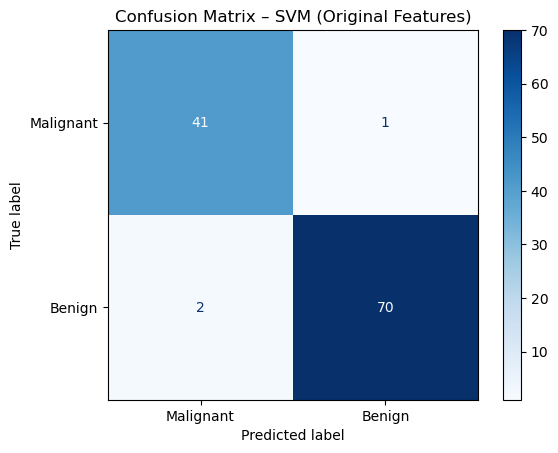

[[41  1]
 [ 2 70]]


In [11]:
# --- Confusion Matrix for the best model: SVM (Original) ---
best_pipe = pipelines['SVM (Original)']
best_pipe.fit(X_train, y_train)
y_pred_best = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – SVM (Original Features)')
plt.show()

print(cm)